In [2]:
# Name :Kunal Ekare
# RollNo: 37
# Batch : B2
# Deep Learning
# Aim : Face Mask Detection System

In [3]:
# Install required libraries
!pip install -q kagglehub tensorflow matplotlib

import kagglehub
import os

# Download latest version from Kaggle
print("Downloading dataset...")
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

# The dataset usually contains a 'data' subfolder with 'with_mask' and 'without_mask'
data_dir = path
if 'data' in os.listdir(path):
    data_dir = os.path.join(path, 'data')

print(f"Dataset is ready at: {data_dir}")
print("Classes found:", os.listdir(data_dir))

100%|██████████| 163M/163M [00:04<00:00, 34.9MB/s]

Extracting files...


Dataset is ready at: /root/.cache/kagglehub/datasets/omkargurav/face-mask-dataset/versions/1/data
Classes found: ['with_mask', 'without_mask']


In [4]:
# Data preprocessing and Agumentation

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define hyperparameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Create an ImageDataGenerator with data augmentation for the training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2 # Reserve 20% of data for validation
)

print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

print("\nLoading Validation Data:")
val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Loading Training Data:
Found 6043 images belonging to 2 classes.

Loading Validation Data:
Found 1510 images belonging to 2 classes.


In [6]:
# Cell 3: Build the MobileNetV2 Model

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load the MobileNetV2 network, ensuring the head FC layer sets are left off
base_model = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Construct the head of the model that will be placed on top of the base model
headModel = base_model.output
headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel) # Prevents overfitting
headModel = Dense(2, activation="softmax")(headModel) # 2 output classes: Mask / No Mask

# Combine the base model and the custom head
model = Model(inputs=base_model.input, outputs=headModel)

# Freeze the base model layers so they aren't updated during the first training process
for layer in base_model.layers:
    layer.trainable = False

# Compile our model
print("Compiling model...")
INIT_LR = 1e-4
EPOCHS = 10

model.compile(loss="categorical_crossentropy",
              optimizer=Adam(learning_rate=INIT_LR),
              metrics=["accuracy"])

print("Model compilation complete! Ready for training.")

/tmp/ipykernel_580/1234489260.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Compiling model...
Model compilation complete! Ready for training.


In [8]:
print("Starting training...")

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

# Save the trained model for future use
model.save("masknet_model.h5")
print("Training complete and model saved as 'masknet_model.h5'")

Starting training...
Epoch 1/10
 28/188 ━━━━━━━━━━━━━━━━━━━━ 1:07 420ms/step - accuracy: 0.5458 - loss: 0.9232

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


188/188 ━━━━━━━━━━━━━━━━━━━━ 149s 683ms/step - accuracy: 0.8840 - loss: 0.2767 - val_accuracy: 0.9581 - val_loss: 0.1039
Epoch 2/10
  1/188 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9688 - loss: 0.1662

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.9688 - loss: 0.1662 - val_accuracy: 0.9707 - val_loss: 0.0912
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 101s 538ms/step - accuracy: 0.9657 - loss: 0.0950 - val_accuracy: 0.9761 - val_loss: 0.0668
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.9062 - loss: 0.1874 - val_accuracy: 0.9747 - val_loss: 0.0729
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 100s 532ms/step - accuracy: 0.9752 - loss: 0.0716 - val_accuracy: 0.9774 - val_loss: 0.0591
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - accuracy: 1.0000 - loss: 0.0741 - val_accuracy: 0.9774 - val_loss: 0.0623
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 144s 765ms/step - accuracy: 0.9787 - loss: 0.0606 - val_accuracy: 0.9754 - val_loss: 0.0682
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - accuracy: 0.9688 - loss: 0.0729 - val_accuracy: 0.9794 - val_loss: 0.0555
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 102s 541ms/step - accuracy: 0.9809 - loss: 0.0515 -

Training complete and model saved as 'masknet_model.h5'


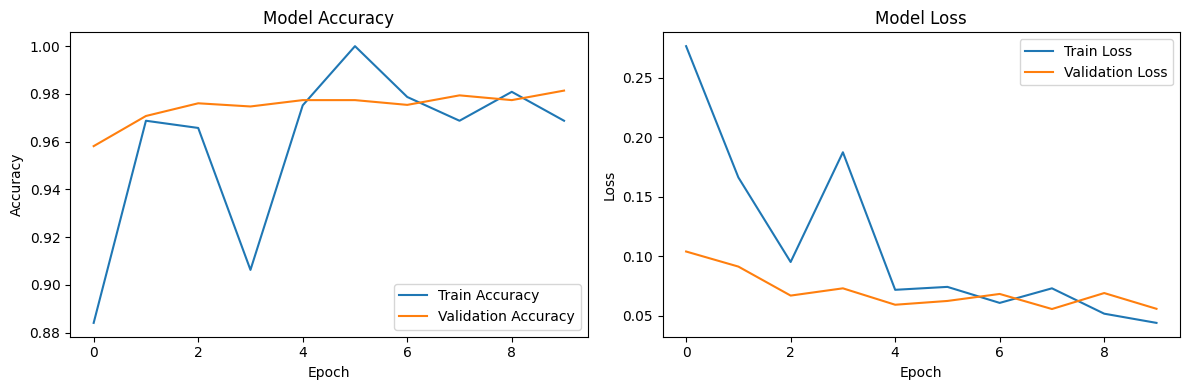

In [9]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Upload an image to test your MaskNet model:


Saving without_mask_13.jpg to without_mask_13.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


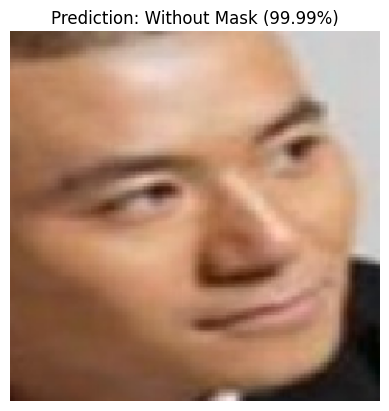

In [11]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from google.colab import files

print("Upload an image to test your MaskNet model:")
uploaded = files.upload()

for fn in uploaded.keys():
    # Predict on the uploaded image
    path = '/content/' + fn
    img = load_img(path, target_size=(224, 224))

    # Preprocess the image
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0 # Scale pixels just like we did in training

    # Make prediction
    predictions = model.predict(img_array)

    # Get class indices mapping (usually {'with_mask': 0, 'without_mask': 1})
    class_indices = train_generator.class_indices
    labels = {v: k for k, v in class_indices.items()}

    # Determine result
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class] * 100
    result = labels[predicted_class]

    # Display result
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {result.replace('_', ' ').title()} ({confidence:.2f}%)")
    plt.show()